In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import ndimage
import glob

RAW_PATH = Path('../data/raw/Original')
CLASSES  = ['Benign', 'Early', 'Pre', 'Pro']
COLORES  = {'Benign': '#2ecc71', 'Early': '#e74c3c', 'Pre': '#e67e22', 'Pro': '#9b59b6'}

print('Librerías cargadas OK')

Librerías cargadas OK


In [3]:
from pathlib import Path
import cv2

def obtener_rutas_imagenes():
    """
    Carga todas las imágenes válidas de data/raw/Original
    """
    RAW_PATH = Path('c:/ProyectoPSIB/leukemia-detection-all-idb/data/raw/Original')
    CLASES   = ['Benign', 'Early', 'Pre', 'Pro']

    dataset = {}
    for cls in CLASES:
        carpeta = RAW_PATH / cls
        imgs = list(carpeta.glob('*.jpg')) + list(carpeta.glob('*.png'))
        imgs_validas = []
        for p in imgs:
            img = cv2.imread(str(p))
            if img is not None and img.mean() >= 5:
                imgs_validas.append(p)
        dataset[cls] = imgs_validas

    todas = [p for paths in dataset.values() for p in paths]

    print('Dataset cargado:')
    for cls, imgs in dataset.items():
        print(f'  {cls:<10}: {len(imgs)} imágenes')
    print(f'  {"Total":<10}: {len(todas)} imágenes')

    return dataset, todas

In [4]:
import cv2
from pathlib import Path

def guardar_imagen_resultado(imagen, ruta_original, carpeta_resultados='../data/resultados/Notebook2/'):
    """
    Guarda la imagen procesada en data/resultados/Notebook2/
    manteniendo la estructura de subcarpetas por clase (Benign, Early, Pre).
    Soporta imágenes RGB a color y máscaras en blanco y negro.
    """
    ruta_original   = Path(ruta_original)
    clase           = ruta_original.parent.name   # ej: 'Benign'
    nombre_archivo  = ruta_original.name          # ej: 'Im001_1.jpg'

    carpeta_destino = Path(carpeta_resultados) / clase
    carpeta_destino.mkdir(parents=True, exist_ok=True)

    ruta_guardado = carpeta_destino / nombre_archivo

    if len(imagen.shape) == 3:  # imagen a color (RGB → BGR para OpenCV)
        imagen_bgr = cv2.cvtColor(imagen, cv2.COLOR_RGB2BGR)
        cv2.imwrite(str(ruta_guardado), imagen_bgr)
    else:  # máscara en blanco y negro
        cv2.imwrite(str(ruta_guardado), imagen)

    return ruta_guardado


In [5]:
def preprocesamiento(img_path, filtro='mediana', ksize=5):
    """
    Pipeline completo de preprocesamiento:
      1. Carga imagen
      2. Convierte a HSV y extrae canal S
      3. Aplica filtro de ruido mediana
    Retorna: imagen original RGB, canal S sin procesar, canal S preprocesado
    """
    img_bgr = cv2.imread(str(img_path))
    
    # Seguro por si alguna ruta se rompe en otra compu
    if img_bgr is None:
        raise FileNotFoundError(f"No se encontró la imagen en: {img_path}")
    

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    canal_s = img_hsv[:,:,1] # Canal S (Saturación - Índice 1)

    if filtro == 'mediana':
        canal_filtrado = cv2.medianBlur(canal_s, ksize)
    elif filtro == 'gaussiano':
        canal_filtrado = cv2.GaussianBlur(canal_s, (ksize, ksize), 0)
    else:
        canal_filtrado = canal_s
        print(f"Filtro '{filtro}' no reconocido. Se devuelve el canal S limpio.")
    
    return img_rgb, canal_s, canal_filtrado

def refinar_mascara_nucleo(mascara, kernel_size=5):
    """
    Aplica operaciones morfológicas para limpiar la máscara del núcleo:
    1. Apertura: elimina pequeños artefactos y puentes finos.
    2. Cierre: rellena huecos internos en el núcleo.
    3. Relleno de agujeros con SciPy: consolida la máscara final.
    """
    # Usamos un elemento estructurante elíptico (ideal para formas redondeadas de núcleos)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    
    # 1. Apertura (Erosión + Dilatación) - Limpia ruidos externos
    apertura = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    
    # 2. Cierre (Dilatación + Erosión) - Conecta componentes del mismo núcleo
    cierre = cv2.morphologyEx(apertura, cv2.MORPH_CLOSE, kernel)
    
    # 3. Relleno de agujeros internos (SciPy ndimage)
    relleno = ndimage.binary_fill_holes(cierre).astype(np.uint8) * 255
    
    # Retornamos los pasos intermedios para tu gráfico de visualización, 
    # siendo 'relleno' el resultado final optimizado.
    return apertura, cierre, relleno


def cargar_imagen(ruta):
    """Carga la imagen y devuelve versiones BGR (para OpenCV) y RGB (para matplotlib)."""
    img_bgr = cv2.imread(ruta)
    if img_bgr is None:
        raise ValueError(f"No se pudo cargar la imagen en la ruta: {ruta}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr, img_rgb


def aislar_celula(img_rgb, mask):
    """
    Multiplica la máscara por la imagen original para dejar solo la célula y el fondo negro.
    """
    # cv2.bitwise_and aplica la máscara a la imagen a color
    celula_aislada = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
    return celula_aislada

def segmentar_celula_otsu(canal_proc, umbral_maximo=45):
    # 1. Aplicamos el método de Otsu normal
    umbral_real, mask_otsu = cv2.threshold(canal_proc, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Aplicamos tu "freno de mano" por si Otsu se va muy alto
    if umbral_real > umbral_maximo:
        _, mask_otsu = cv2.threshold(canal_proc, umbral_maximo, 255, cv2.THRESH_BINARY)
        
    # ==========================================================
    # 2. MORFOLOGÍA MATEMÁTICA ASIMÉTRICA (SEPARAR Y EXPANDIR)
    # ==========================================================
    # Creamos pinceles (kernels) redondos porque las células son circulares
    kernel_romper = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    kernel_expandir = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)) # ¡Más grande!
    
    # PASO A (Erosión): "Comemos" los bordes de todas las células. 
    # Esto debilita y rompe la unión en el medio de las células siamesas.
    # Si notas que siguen pegadas en algunas fotos, sube iterations a 3.
    mask_erosionada = cv2.erode(mask_otsu, kernel_romper, iterations=2)
    
    # PASO B (Dilatación): Volvemos a inflar los pedazos que sobrevivieron.
    # Como usamos un kernel de 9x9 (mayor al de 7x7), la célula final quedará 
    # separada de su vecina, pero será ligeramente MÁS GRANDE que la original.
    mask_separada = cv2.dilate(mask_erosionada, kernel_expandir, iterations=2)
    
    return mask_separada, umbral_real

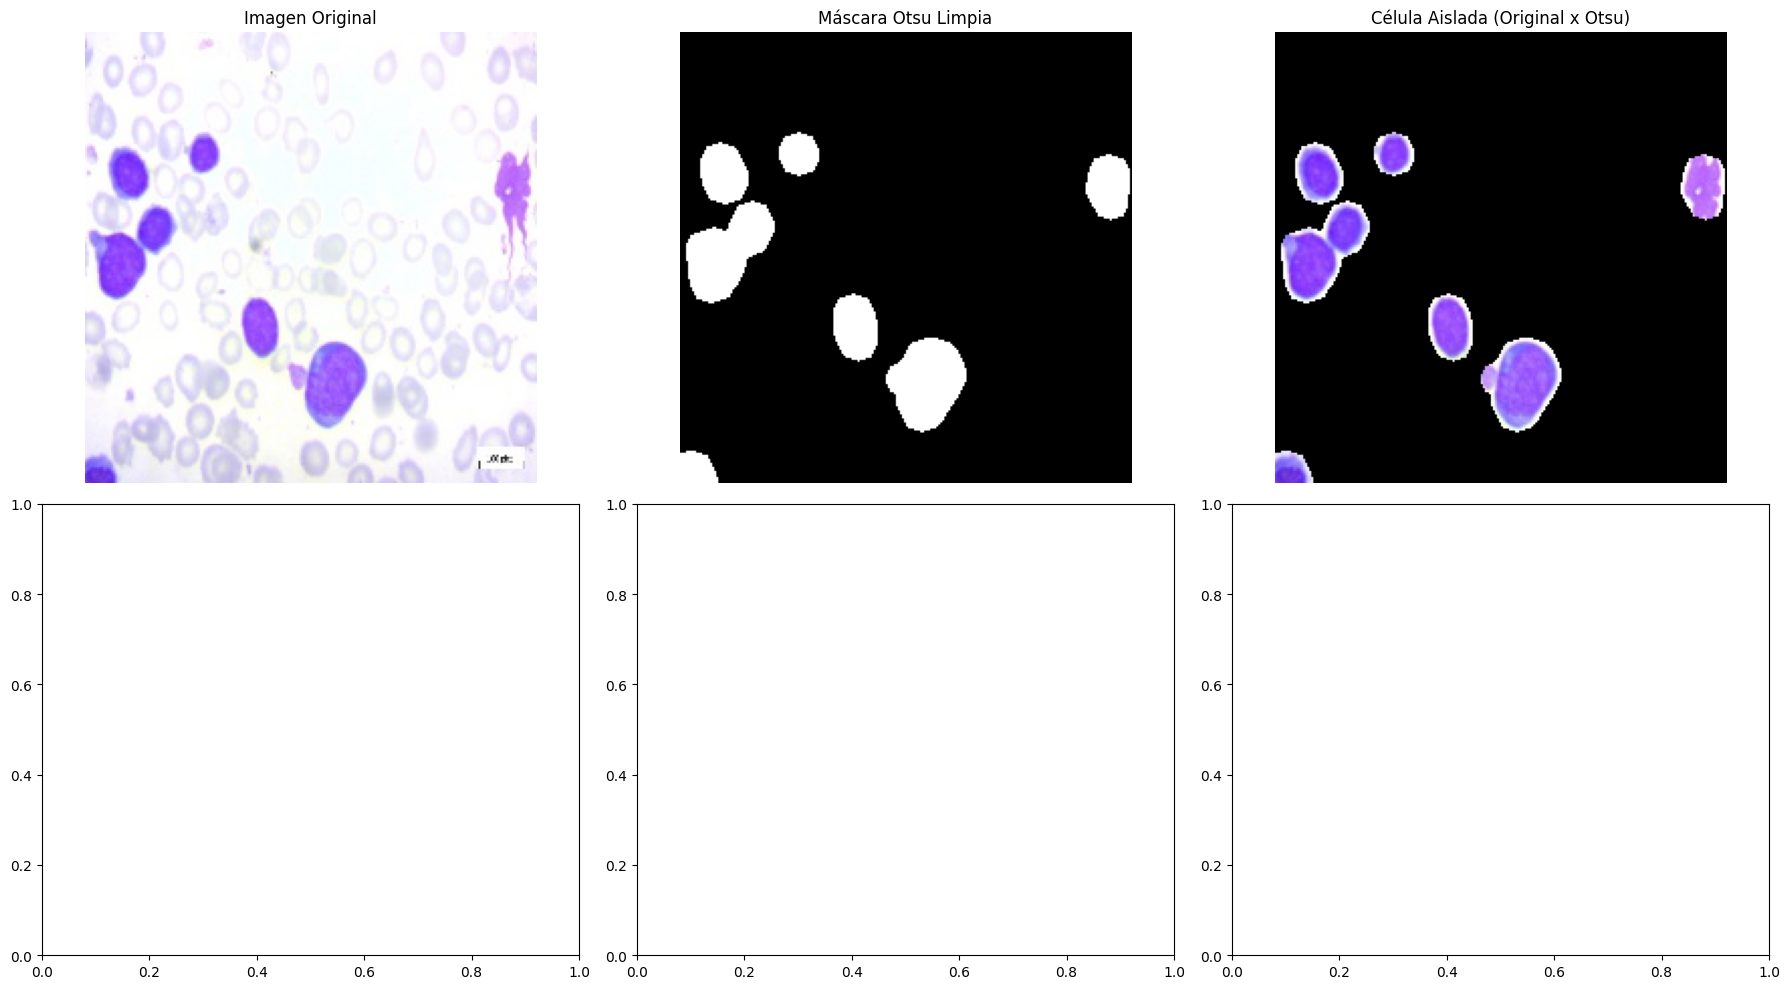

In [6]:
# --- 1. CARGA DE IMAGEN ---
# ¡Asegúrate de cambiar este nombre por el de una de tus imágenes de prueba!
cls = 'Benign'  # Cambia esto por 'Early', 'Pre' o 'Pro' para probar otras clases
ruta_imagen = list((RAW_PATH / cls).glob('*.jpg'))[0]  # Tomamos la primera imagen de la clase seleccionada

img_bgr, img_rgb = cargar_imagen(ruta_imagen)

# Paso A: Preprocesamiento (Tu pipeline del Canal S)
img_rgb, canal_s_raw, canal_proc = preprocesamiento(ruta_imagen, filtro='mediana', ksize=5)
    
# Paso B: Segmentación con el NUEVO freno de mano en 70
mask_raw, umbral_calc = segmentar_celula_otsu(canal_proc, umbral_maximo=45)
    
# Paso C: Refinamiento morfológico con el kernel elíptico
apertura, cierre, relleno = refinar_mascara_nucleo(mask_raw, kernel_size=5)
# --- 2. APLICAR MÉTODOS ---
# Otsu

resultado_otsu = aislar_celula(img_rgb, mask_raw)

# --- 3. MOSTRAR RESULTADOS ---
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Fila 1: Otsu
axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title("Imagen Original")
axs[0, 0].axis('off')

axs[0, 1].imshow(mask_raw, cmap='gray')
axs[0, 1].set_title("Máscara Otsu Limpia")
axs[0, 1].axis('off')

axs[0, 2].imshow(resultado_otsu)
axs[0, 2].set_title("Célula Aislada (Original x Otsu)")
axs[0, 2].axis('off')



plt.tight_layout()
plt.show()

In [7]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def clasificar_y_filtrar_linfocitos(mascara_celula, mascara_nucleo, imagen_original, area_minima=100, area_maxima=1000):
    # ==========================================
    # 1. PARCHE DE SEGURIDAD (Evita errores de OpenCV)
    # ==========================================
    mascara_celula = np.array(mascara_celula, dtype=np.uint8)
    if mascara_celula.max() == 1: mascara_celula *= 255
        
    mascara_nucleo = np.array(mascara_nucleo, dtype=np.uint8)
    if mascara_nucleo.max() == 1: mascara_nucleo *= 255
        
    # ==========================================
    # 2. INICIO DE LA FUNCIÓN
    # ==========================================
    contornos_celula, _ = cv2.findContours(mascara_celula, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    mascara_linfocitos = np.zeros_like(mascara_celula)
    caracteristicas_extraidas = []
    
    imagen_gris = cv2.cvtColor(imagen_original, cv2.COLOR_RGB2GRAY)
    
    for cnt in contornos_celula:
        area_celula = cv2.contourArea(cnt)
        
        # ==========================================
        # FILTRO DE ÁREA (Parametrizado)
        # ==========================================
        if area_celula < area_minima or area_celula > area_maxima:
            continue
            
        perimetro_celula = cv2.arcLength(cnt, True)
        if perimetro_celula == 0: continue
            
        circularidad_celula = 4 * np.pi * (area_celula / (perimetro_celula * perimetro_celula))
        hull_celula = cv2.convexHull(cnt)
        solidez_celula = area_celula / float(cv2.contourArea(hull_celula)) if cv2.contourArea(hull_celula) > 0 else 0
        
        # --- ANÁLISIS DEL NÚCLEO ---
        mask_esta_celula = np.zeros_like(mascara_celula)
        cv2.drawContours(mask_esta_celula, [cnt], -1, 255, thickness=cv2.FILLED)
        
        nucleo_aislado = cv2.bitwise_and(mascara_nucleo, mascara_nucleo, mask=mask_esta_celula)
        contornos_nuc, _ = cv2.findContours(nucleo_aislado, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contornos_nuc) == 0: continue 
            
        cnt_nucleo = max(contornos_nuc, key=cv2.contourArea)
        area_nuc = cv2.contourArea(cnt_nucleo)
        peri_nuc = cv2.arcLength(cnt_nucleo, True)
        
        circularidad_nucleo = 4 * np.pi * (area_nuc / (peri_nuc * peri_nuc)) if peri_nuc > 0 else 0
        
        hull_nuc = cv2.convexHull(cnt_nucleo)
        solidez_nucleo = area_nuc / float(cv2.contourArea(hull_nuc)) if cv2.contourArea(hull_nuc) > 0 else 0
        
        # --- TEXTURA ---
        media_color, std_color = cv2.meanStdDev(imagen_gris, mask=nucleo_aislado)
        textura_nucleo = std_color[0][0] if std_color is not None else 0
            
        # --- REGLA DE ORO ---
        es_linfocito = (solidez_nucleo > 0.8) and (circularidad_nucleo > 0.65)
        
        if es_linfocito:
            cv2.drawContours(mascara_linfocitos, [cnt], -1, 255, thickness=cv2.FILLED)
            caracteristicas_extraidas.append({
                'Area_Celula': area_celula,
                'Solidez_Nuc': round(solidez_nucleo, 2),
                'Circ_Nuc': round(circularidad_nucleo, 2),
                'Textura_Nuc': round(textura_nucleo, 2)
            })
            
    img_limpia = cv2.bitwise_and(imagen_original, imagen_original, mask=mascara_linfocitos)
    return mascara_linfocitos, img_limpia, caracteristicas_extraidas

In [8]:
def segmentar_nucleo_estricto(canal_proc):
    """Genera la máscara marcando solo los núcleos usando el método de Otsu original.
    Ideal para medir luego la circularidad del núcleo y descartar neutrófilos.
    """
    # 1. Otsu matemático normal (encuentra lo más oscuro/saturado por sí solo)
    umbral_otsu, mascara_nucleo = cv2.threshold(
        canal_proc, 0, 255, 
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    # 2. Pequeño cierre morfológico para que el núcleo no tenga "agujeros" negros adentro
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mascara_nucleo_limpia = cv2.morphologyEx(mascara_nucleo, cv2.MORPH_CLOSE, kernel)
    
    return mascara_nucleo_limpia

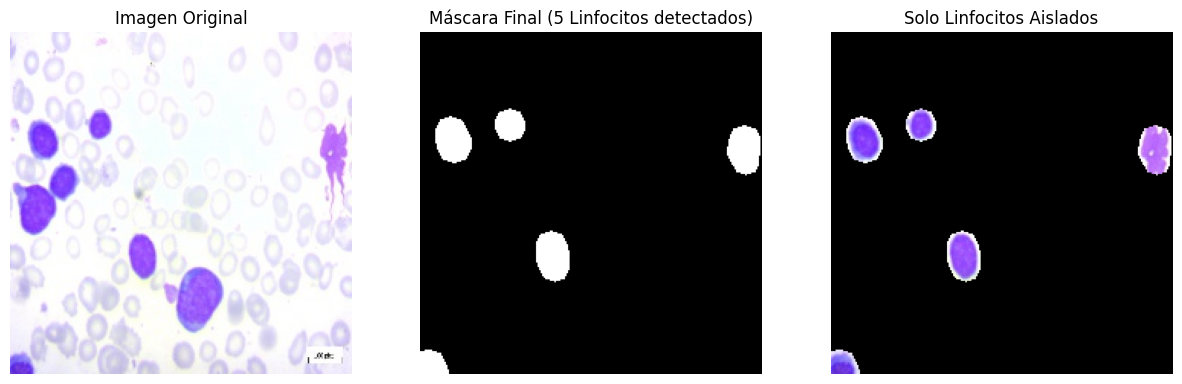

   Area_Celula  Solidez_Nuc  Circ_Nuc  Textura_Nuc
0        221.0         0.98      0.77        29.08
1        555.5         0.98      0.82        13.74
2        527.0         0.92      0.66        15.79
3        531.5         0.97      0.85        23.74
4        307.0         0.98      0.88        19.50


In [9]:
# Suponiendo que 'mask_raw' es la máscara que salió de Otsu 
# 'img_rgb' es tu imagen original a color
# y 'mascara_nucleos' es tu máscara de núcleos unicamente

mascara_nucleos = segmentar_nucleo_estricto(canal_proc)

mascara_filtrada, img_limpia, datos = clasificar_y_filtrar_linfocitos(mask_raw, mascara_nucleos, img_rgb)

mascara_filtrada

# Mostrar el resultado de la limpieza
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(img_rgb)
axs[0].set_title("Imagen Original")
axs[0].axis('off')

axs[1].imshow(mascara_filtrada, cmap='gray')
axs[1].set_title(f"Máscara Final ({len(datos)} Linfocitos detectados)")
axs[1].axis('off')

axs[2].imshow(img_limpia)
axs[2].set_title("Solo Linfocitos Aislados")
axs[2].axis('off')

plt.show()

# Ver los datos matemáticos extraídos
df_celulas = pd.DataFrame(datos)
print(df_celulas)

In [10]:
"Comentarios:"
"- Falta agregar una forma para cuando hay celulas muy pegadas las diferencie. "
"porque al tomar las 2 juntas la funcion clasificar_y_filtrar_linfocitos no elimina las mas chicas que "
"esten pegadas a un linfocito "

"- Falta filtrar a algunos basofilos: en teoria clasificar_y_filtrar_linfocitos los filtra por la"
" solidez del nucleo pero hay algunos que no son eliminados correctamente, al intentar subir el"
" valor de solidez deberia eliminarlos pero tambien elimina algunos linfocitos"

' valor de solidez deberia eliminarlos pero tambien elimina algunos linfocitos'

In [11]:
import pandas as pd
from pathlib import Path

# 1. Cargar imágenes válidas desde JSON
dataset, rutas_todas = obtener_rutas_imagenes()

print(f'\nTotal de imágenes a procesar: {len(rutas_todas)}')
print('Iniciando pipeline...\n')

base_datos_celulas = []
ok, errores = 0, 0

# ========================================================
# MOTOR PRINCIPAL
# Nota: rutas_todas[0:5] procesa solo 5 imágenes de prueba.
# Para procesar todas: for ruta in rutas_todas:
# ========================================================
for ruta in rutas_todas[0:10]:
    try:
        # A. Preprocesamiento
        img_rgb, _, canal_filtrado = preprocesamiento(ruta, filtro='mediana', ksize=5)

        # B. Segmentación del núcleo
        masc_nuc = segmentar_nucleo_estricto(canal_filtrado)

        # C. Segmentación de la célula completa
        masc_cel_bruta, _ = segmentar_celula_otsu(canal_filtrado, umbral_maximo=45)
        _, _, masc_cel_limpia = refinar_mascara_nucleo(masc_cel_bruta, kernel_size=5)

        # D. Filtrado de linfocitos
        masc_final, img_limpia, caracteristicas = clasificar_y_filtrar_linfocitos(
            masc_cel_limpia, masc_nuc, img_rgb
        )

        # E. Guardar imagen procesada en resultados/Notebook2/
        guardar_imagen_resultado(
            img_limpia, ruta,
            carpeta_resultados='../data/resultados/Notebook2/'
        )

        # F. Registrar métricas
        for celula in caracteristicas:
            celula['Nombre_Archivo'] = ruta.name
            celula['Clase']          = ruta.parent.name
            base_datos_celulas.append(celula)

        ok += 1
        print(f'OK  {ruta.parent.name}/{ruta.name} | Células: {len(caracteristicas)}')

    except Exception as e:
        errores += 1
        print(f'ERR {ruta.name}: {e}')

# ========================================================
# GUARDAR MÉTRICAS EN CSV
# ========================================================
print(f'\nProcesadas: {ok} | Errores: {errores}')

if base_datos_celulas:
    df_resultados = pd.DataFrame(base_datos_celulas)
    csv_path = Path('../data/resultados/Notebook2/metricas_linfocitos.csv')
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    df_resultados.to_csv(csv_path, index=False, encoding='utf-8')
    print(f'CSV guardado en: {csv_path}')
    print(df_resultados.head())
else:
    print('No se extrajeron células. Revisar pipeline.')


Dataset cargado:
  Benign    : 504 imágenes
  Early     : 985 imágenes
  Pre       : 963 imágenes
  Pro       : 804 imágenes
  Total     : 3256 imágenes

Total de imágenes a procesar: 3256
Iniciando pipeline...

OK  Benign/WBC-Benign-001.jpg | Células: 4
OK  Benign/WBC-Benign-002.jpg | Células: 9
OK  Benign/WBC-Benign-003.jpg | Células: 10
OK  Benign/WBC-Benign-004.jpg | Células: 3
OK  Benign/WBC-Benign-005.jpg | Células: 3
OK  Benign/WBC-Benign-006.jpg | Células: 1
OK  Benign/WBC-Benign-007.jpg | Células: 4
OK  Benign/WBC-Benign-008.jpg | Células: 3
OK  Benign/WBC-Benign-009.jpg | Células: 8
OK  Benign/WBC-Benign-010.jpg | Células: 5

Procesadas: 10 | Errores: 0
CSV guardado en: ..\data\resultados\Notebook2\metricas_linfocitos.csv
   Area_Celula  Solidez_Nuc  Circ_Nuc  Textura_Nuc      Nombre_Archivo   Clase
0        220.5         0.98      0.77        29.08  WBC-Benign-001.jpg  Benign
1        552.0         0.98      0.82        13.74  WBC-Benign-001.jpg  Benign
2        552.5       

In [12]:
# Contadores de control
ok = 0
errores = 0

print("--- Iniciando Pipeline de Segmentación ---")

for ruta in rutas_todas:
    try:
        # A. Preprocesamiento de canales
        img_rgb, _, canal_filtrado = preprocesamiento(ruta)
        
        # B. Segmentación del núcleo
        masc_nuc = segmentar_nucleo_estricto(canal_filtrado)
        
        # C. Segmentación celular + morfología asimétrica anti-siamesas
        masc_cel_bruta, _ = segmentar_celula_otsu(canal_filtrado, umbral_maximo=45)
        _, _, masc_cel_limpia = refinar_mascara_nucleo(masc_cel_bruta, kernel_size=5)
        
        # D. Filtrado definitivo aplicando la regla de oro
        masc_final, img_limpia, linfocitos_detectados = clasificar_y_filtrar_linfocitos(masc_cel_limpia, masc_nuc, img_rgb)
        
        # E. Guardado directo de la imagen recortada limpia
        guardar_imagen_resultado(img_limpia, ruta, carpeta_resultados='../data/resultados/Notebook3/')
        
        ok += 1
        print(f"✅ OK {ruta.parent.name}/{ruta.name} | Linfocitos filtrados: {len(linfocitos_detectados)}")
        
    except Exception as e:
        errores += 1
        print(f"❌ ERR en {ruta.name}: {e}")

print(f'\n--- ¡Proceso terminado con éxito! ---')
print(f'✔️ Imágenes procesadas de forma limpia: {ok}')
print(f'❌ Errores en la iteración: {errores}')

--- Iniciando Pipeline de Segmentación ---
✅ OK Benign/WBC-Benign-001.jpg | Linfocitos filtrados: 4
✅ OK Benign/WBC-Benign-002.jpg | Linfocitos filtrados: 9
✅ OK Benign/WBC-Benign-003.jpg | Linfocitos filtrados: 10
✅ OK Benign/WBC-Benign-004.jpg | Linfocitos filtrados: 3
✅ OK Benign/WBC-Benign-005.jpg | Linfocitos filtrados: 3
✅ OK Benign/WBC-Benign-006.jpg | Linfocitos filtrados: 1
✅ OK Benign/WBC-Benign-007.jpg | Linfocitos filtrados: 4
✅ OK Benign/WBC-Benign-008.jpg | Linfocitos filtrados: 3
✅ OK Benign/WBC-Benign-009.jpg | Linfocitos filtrados: 8
✅ OK Benign/WBC-Benign-010.jpg | Linfocitos filtrados: 5
✅ OK Benign/WBC-Benign-011.jpg | Linfocitos filtrados: 10
✅ OK Benign/WBC-Benign-012.jpg | Linfocitos filtrados: 5
✅ OK Benign/WBC-Benign-013.jpg | Linfocitos filtrados: 7
✅ OK Benign/WBC-Benign-014.jpg | Linfocitos filtrados: 6
✅ OK Benign/WBC-Benign-015.jpg | Linfocitos filtrados: 9
✅ OK Benign/WBC-Benign-016.jpg | Linfocitos filtrados: 5
✅ OK Benign/WBC-Benign-017.jpg | Linfocitos

In [13]:
import cv2
import numpy as np
from pathlib import Path

# Configuración de las rutas
RESULT_PATH = Path('../data/resultados/Notebook3')
CLASSES = ['Benign', 'Early', 'Pre', 'Pro']

estadisticas = {
    'Benign': {'total': 0, 'cancerigenas': 0},
    'Early': {'total': 0, 'cancerigenas': 0},
    'Pre': {'total': 0, 'cancerigenas': 0},
    'Pro': {'total': 0, 'cancerigenas': 0}
}

UMBRAL_NC = 0.75 

print("--- Iniciando Clasificación de Leucemia (Relación N/C Adaptativa) ---")

for clase in CLASSES:
    carpeta_clase = RESULT_PATH / clase
    imagenes = list(carpeta_clase.glob('*.jpg')) + list(carpeta_clase.glob('*.png'))
    
    estadisticas[clase]['total'] = len(imagenes)
    
    for ruta in imagenes:
        img_bgr = cv2.imread(str(ruta))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_gris = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        
        # Máscara de la Célula entera (El fondo negro nos regala la máscara)
        _, masc_celula = cv2.threshold(img_gris, 10, 255, cv2.THRESH_BINARY)
        
        # Preparar el canal óptico para el núcleo
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        canal_b = img_lab[:, :, 2]
        canal_inv = cv2.bitwise_not(canal_b)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        canal_optico = clahe.apply(canal_inv)
        
        contornos_celula, _ = cv2.findContours(masc_celula, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        imagen_es_cancerigena = False
        
        for cnt in contornos_celula:
            area_celula = cv2.contourArea(cnt)
            if area_celula < 1000: continue 
            
            # Aislar solo el sector de la imagen que pertenece a ESTA célula
            mask_esta_celula = np.zeros_like(masc_celula)
            cv2.drawContours(mask_esta_celula, [cnt], -1, 255, thickness=cv2.FILLED)
            
            # ==========================================================
            # LA MAGIA: Otsu Local (Adaptativo a la coloración de la célula)
            # ==========================================================
            # Extraemos solo los valores de los píxeles que están dentro de la célula
            pixeles_celula = canal_optico[mask_esta_celula == 255]
            
            if len(pixeles_celula) > 0:
                # Otsu calcula el punto de corte ideal solo evaluando los tonos de esa célula
                umbral_otsu, _ = cv2.threshold(pixeles_celula, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
                
                # Aplicamos el umbral adaptativo
                _, nucleo_binario = cv2.threshold(canal_optico, umbral_otsu, 255, cv2.THRESH_BINARY)
                
                # Nos aseguramos de que no desborde la célula
                nucleo_aislado = cv2.bitwise_and(nucleo_binario, nucleo_binario, mask=mask_esta_celula)
                
                contornos_nuc, _ = cv2.findContours(nucleo_aislado, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                
                if len(contornos_nuc) > 0:
                    cnt_nucleo = max(contornos_nuc, key=cv2.contourArea)
                    area_nucleo = cv2.contourArea(cnt_nucleo)
                    
                    # Cálculo de la Relación N/C
                    ratio_nc = area_nucleo / area_celula
                    
                    if ratio_nc > UMBRAL_NC:
                        imagen_es_cancerigena = True
                        break 
                        
        if imagen_es_cancerigena:
            estadisticas[clase]['cancerigenas'] += 1

# Imprimir Resultados
print("\n📊 RESULTADOS FINALES DE CLASIFICACIÓN (Relación N/C > 0.75):")
for clase in CLASSES:
    totales = estadisticas[clase]['total']
    cancer = estadisticas[clase]['cancerigenas']
    porcentaje = (cancer / totales * 100) if totales > 0 else 0
    
    print(f"🔸 Carpeta {clase.upper()}:")
    print(f"   - Imágenes válidas procesadas: {totales}")
    print(f"   - Diagnosticadas con cáncer: {cancer} ({porcentaje:.1f}%)")
    print("-" * 40)

--- Iniciando Clasificación de Leucemia (Relación N/C Adaptativa) ---

📊 RESULTADOS FINALES DE CLASIFICACIÓN (Relación N/C > 0.75):
🔸 Carpeta BENIGN:
   - Imágenes válidas procesadas: 504
   - Diagnosticadas con cáncer: 0 (0.0%)
----------------------------------------
🔸 Carpeta EARLY:
   - Imágenes válidas procesadas: 985
   - Diagnosticadas con cáncer: 0 (0.0%)
----------------------------------------
🔸 Carpeta PRE:
   - Imágenes válidas procesadas: 963
   - Diagnosticadas con cáncer: 0 (0.0%)
----------------------------------------
🔸 Carpeta PRO:
   - Imágenes válidas procesadas: 804
   - Diagnosticadas con cáncer: 0 (0.0%)
----------------------------------------


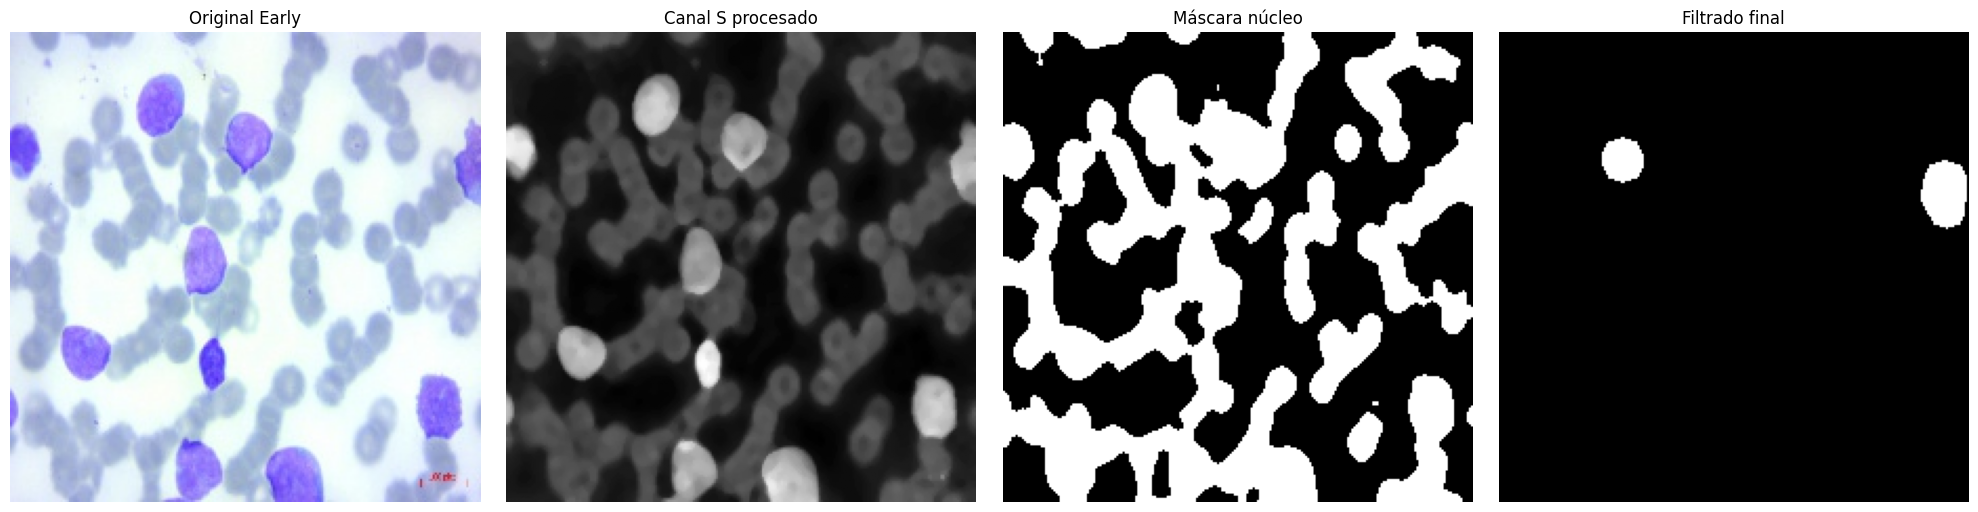

   Area_Celula  Solidez_Nuc  Circ_Nuc  Textura_Nuc
0        527.0         0.89      0.70        23.76
1        307.0         0.94      0.72         7.33


In [14]:
# Probar con una imagen Early
cls = 'Early'
ruta_imagen = list((RAW_PATH / cls).glob('*.jpg'))[2]

img_rgb, canal_s_raw, canal_proc = preprocesamiento(ruta_imagen, filtro='mediana', ksize=5)
mascara_nucleos = segmentar_nucleo_estricto(canal_proc)
mascara_filtrada, img_limpia, datos = clasificar_y_filtrar_linfocitos(mask_raw, mascara_nucleos, img_rgb)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(img_rgb);                        axs[0].set_title('Original Early');     axs[0].axis('off')
axs[1].imshow(canal_proc, cmap='gray');        axs[1].set_title('Canal S procesado');  axs[1].axis('off')
axs[2].imshow(mascara_nucleos, cmap='gray');   axs[2].set_title('Máscara núcleo');     axs[2].axis('off')
axs[3].imshow(mascara_filtrada, cmap='gray');  axs[3].set_title('Filtrado final');     axs[3].axis('off')
plt.tight_layout()
plt.show()
print(pd.DataFrame(datos))